<a href="https://colab.research.google.com/github/astridcvr/daily-ml-practice/blob/main/day_20_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading datasets from GitHub...

Shapes:
X_train: (2258, 48) X_test: (565, 48)
y_train: (2258, 1) y_test: (565, 1)

Numeric dataset:
X_train_num: (2258, 8) X_test_num: (565, 8)

Training Random Forest model...
Model trained successfully.

Top features:

           Feature  Importance
2        PRICEEACH    0.506051
1  QUANTITYORDERED    0.336761
7             MSRP    0.106508
0      ORDERNUMBER    0.024255
3  ORDERLINENUMBER    0.013706

Feature importance saved locally: day_20_feature_importance.csv


,Feature,Importance
2,PRICEEACH,0.506051
1,QUANTITYORDERED,0.336761
7,MSRP,0.106508
0,ORDERNUMBER,0.024255
3,ORDERLINENUMBER,0.013706
5,MONTH_ID,0.009152
4,QTR_ID,0.002103
6,YEAR_ID,0.001464


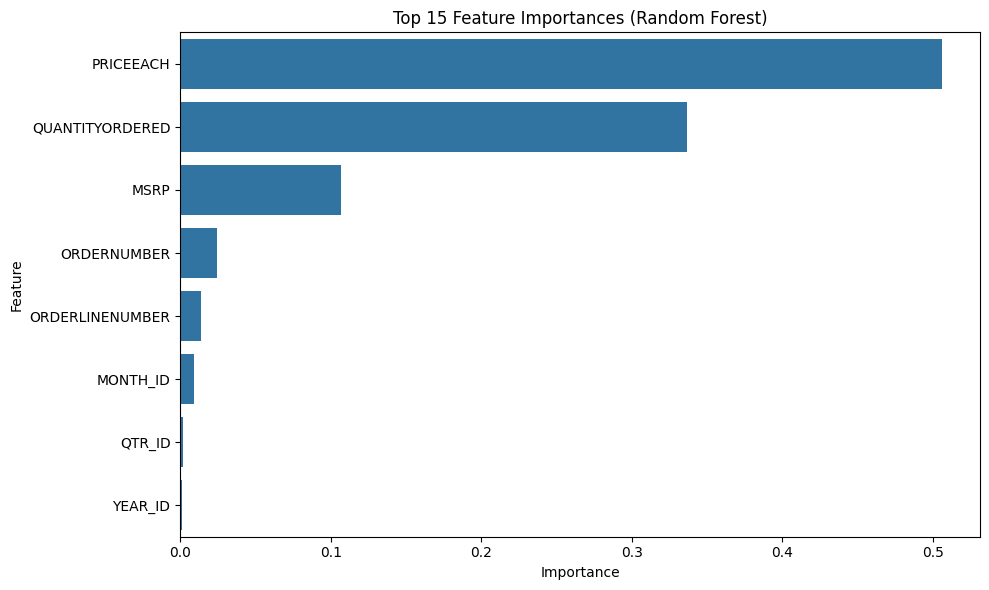

In [1]:
# ============================================================
# Day 20: Feature Importance / Jour 20 : Importance des variables
# Identify key variables using RandomForest feature importance.
# Identifier les variables clés grâce à l'importance du modèle RandomForest.
# ============================================================

# === 1. Import libraries / Importer les bibliothèques ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# === 2. Load datasets from GitHub / Charger les jeux depuis GitHub ===
print("Loading datasets from GitHub...\n")

X_train = pd.read_csv("https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/X_train.csv")
X_test  = pd.read_csv("https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/X_test.csv")
y_train = pd.read_csv("https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/y_train.csv")
y_test  = pd.read_csv("https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/y_test.csv")

print("Shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

# === 3. Keep only numeric columns / Ne garder que les colonnes numériques ===
X_train_num = X_train.select_dtypes(include=['int64', 'float64'])
X_test_num  = X_test.select_dtypes(include=['int64', 'float64'])

print("\nNumeric dataset:")
print("X_train_num:", X_train_num.shape, "X_test_num:", X_test_num.shape)

# === 4. Train Random Forest / Entraîner le modèle RandomForest ===
print("\nTraining Random Forest model...")
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train_num, y_train.values.ravel())

print("Model trained successfully.\n")

# === 5. Extract feature importance / Extraire l'importance des variables ===
importances = rf.feature_importances_
features = X_train_num.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("Top features:\n")
print(importance_df.head())

# === 6. Save results locally / Enregistrer les résultats localement ===
output_path = "day_20_feature_importance.csv"
importance_df.to_csv(output_path, index=False)

print(f"\nFeature importance saved locally: {output_path}")
display(importance_df.head(10))

# === 7. Visualization / Visualisation ===
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
